In [1]:
#pip install python-igraph matplotlib

In [2]:
#pip install pycairo

In [1]:
import igraph as ig
import re
import infomap

In [2]:
def load_edgelist(filepath):
    edges = []
    with open(filepath, "r") as f:
        for line in f:
            if line.startswith("%") or line.strip() == "":
                continue
            
            try:
                src, dst = map(int, re.split(r"[,\s]+", line.strip()))
                edges.append((src, dst))
            except:
                continue
    print(f"Loaded {len(edges)} edges")
    return edges

Greek Wikipedia:

In [3]:
file_path = r"..\data\wikipedia_link_el.edges"

edges = load_edgelist(file_path)

# Create graph
g = ig.Graph(edges=edges, directed=True)

print(g.summary())

Loaded 5890410 edges
IGRAPH D--- 216366 5890410 -- 


In [4]:
g_undirected = g.as_undirected()
components = g_undirected.connected_components()
giant = components.giant()

print(giant.summary())

IGRAPH U--- 216228 4719013 -- 


In [5]:
clusters_giant = giant.community_infomap()

print("Communities in giant component:", len(clusters_giant))
print("Codelength:", clusters_giant.codelength)

Communities in giant component: 3252
Codelength: 12.856594957215858


In [ ]:
result = infomap.run(giant, seed=123, num_trials=20)

print(result.num_top_modules, result.codelength)
print(result.modules())  # {node_id: module_id}

German wikipedia:

In [ ]:

file_path = r"data\wikipedia_link_de.edges"

edges = load_edgelist(file_path)

# Create graph
g = ig.Graph(edges=edges, directed=True)

print(g.summary())

Loaded 2057583 edges
IGRAPH D--- 3930075 2057583 -- 


In [ ]:
g_undirected = g.as_undirected()

clusters = g_undirected.community_multilevel()

print("Number of communities:", len(clusters))

Number of communities: 3410333


In [ ]:
components = g_undirected.clusters()

giant = components.giant()

print(giant.summary())

C:\Users\ttuni\AppData\Local\Temp\ipykernel_22016\1393790734.py:1: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  components = g_undirected.clusters()


IGRAPH U--- 519671 2052331 -- 


In [ ]:
clusters_giant = giant.community_multilevel()

print("Communities in giant component:", len(clusters_giant))

Communities in giant component: 27


In [ ]:
import igraph as ig
import numpy as np

membership = clusters_giant.membership
num_comms = len(clusters_giant)
print(f"Number of communities: {num_comms}")

comm_sizes = clusters_giant.sizes()
edge_counts = np.zeros((num_comms, num_comms))
possible_edges = np.zeros((num_comms, num_comms))

for e in giant.es:
    src = e.source
    tgt = e.target
    c_i = membership[src]
    c_j = membership[tgt]
    edge_counts[c_i, c_j] += 1

for i in range(num_comms):
    for j in range(num_comms):
        if i == j:
            # self-loop: exclude self-to-self node pairs
            possible_edges[i, j] = comm_sizes[i] * (comm_sizes[i] - 1)
        else:
            possible_edges[i, j] = comm_sizes[i] * comm_sizes[j]

with np.errstate(divide='ignore', invalid='ignore'):
    weights = np.divide(edge_counts, possible_edges)
    weights[np.isnan(weights)] = 0

compressed_graph = ig.Graph(directed=True)
compressed_graph.add_vertices(num_comms)
edges = []
edge_weights = []

for i in range(num_comms):
    for j in range(num_comms):
        if weights[i, j] > 0:
            edges.append((i, j))
            edge_weights.append(weights[i, j])

compressed_graph.add_edges(edges)
compressed_graph.es["weight"] = edge_weights

print(compressed_graph.summary())


Number of communities: 27
IGRAPH D-W- 27 440 -- 
+ attr: weight (e)


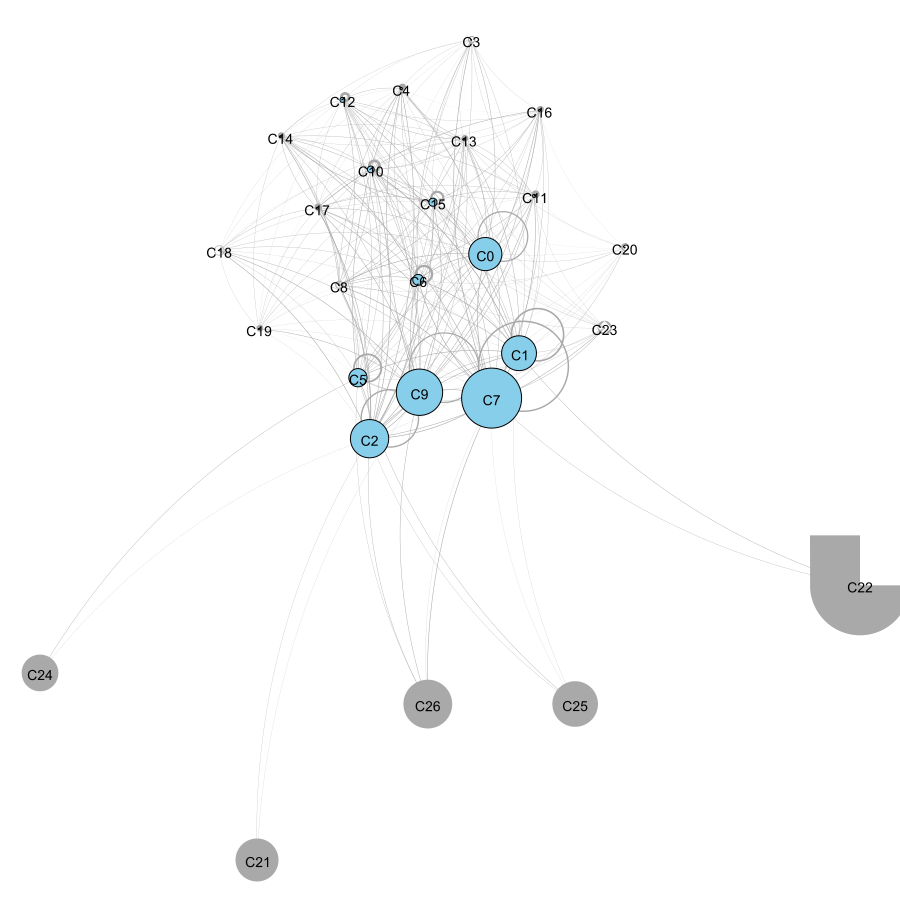

In [ ]:
import math

g_plot = compressed_graph.as_undirected(combine_edges="sum")
vertex_sizes = [s / max(comm_sizes) * 60 for s in comm_sizes]
weights = g_plot.es["weight"]
edge_widths = [math.sqrt(w * 50000) for w in weights]
layout = g_plot.layout("fr")
ig.plot(
    g_plot,
    layout=layout,
    vertex_size=vertex_sizes,
    vertex_color="skyblue",
    vertex_label=[f"C{i}" for i in range(num_comms)],
    edge_width=edge_widths,
    edge_color="darkgray",
    edge_curved=0.2,
    bbox=(900, 900),
    margin=40
)

### English Wikipedia (lord help me)

In [ ]:
import igraph as ig

file_path = r"data\wikipedia_link_en.edges"
edges = []

with open(file_path, "r") as f:
    for line in f:
        # Skip header/comment lines
        if line.startswith("%") or line.strip() == "":
            continue
        
        # Split by comma instead of space
        try:
            src, dst = map(int, line.strip().split(","))
            edges.append((src, dst))
        except:
            continue

print(f"Loaded {len(edges)} edges")

# Create graph
g = ig.Graph(edges=edges, directed=True)

print(g.summary())

Loaded 31956268 edges
IGRAPH D--- 27154757 31956268 -- 


In [ ]:
seen = set()
has_multi = False

with open(file_path, "r") as f:
    for line in f:
        if line.startswith("%") or line.strip() == "":
            continue
        
        try:
            src, dst = map(int, line.strip().split(","))
            edge = (src, dst)

            if edge in seen:
                has_multi = True
                print("Found a multiedge:", edge)
                break
            seen.add(edge)

        except:
            continue

print("Has multiedges:", has_multi)

Found a multiedge: (2, 14637549)
Has multiedges: True


In [ ]:
#g_undirected = g.as_undirected()
clusters = g.community_infomap()
components = g.clusters()
giant = components.giant()

print(giant.summary())

clusters_giant = giant.community_infomap()

print("Communities in giant component:", len(clusters_giant))

In [ ]:
print("Total number of nodes:", g.vcount())
print("Total number of edges:", g.ecount())

print("Nodes in giant component:", giant.vcount())
print("Edges in giant component:", giant.ecount())

In [ ]:
sizes = components.sizes()
sizes = sorted(sizes, reverse=True)

print("Largest components:")
for i in range(10):
    print(f"{i+1}: {sizes[i]}")
    


In [ ]:
membership = clusters_giant.membership
num_comms = len(clusters_giant)
print(f"Number of communities: {num_comms}")

comm_sizes = clusters_giant.sizes()
edge_counts = np.zeros((num_comms, num_comms))
possible_edges = np.zeros((num_comms, num_comms))

for e in giant.es:
    src = e.source
    tgt = e.target
    c_i = membership[src]
    c_j = membership[tgt]
    edge_counts[c_i, c_j] += 1

for i in range(num_comms):
    for j in range(num_comms):
        if i == j:
            # self-loop: exclude self-to-self node pairs
            possible_edges[i, j] = comm_sizes[i] * (comm_sizes[i] - 1)
        else:
            possible_edges[i, j] = comm_sizes[i] * comm_sizes[j]

with np.errstate(divide='ignore', invalid='ignore'):
    weights = np.divide(edge_counts, possible_edges)
    weights[np.isnan(weights)] = 0

compressed_graph = ig.Graph(directed=True)
compressed_graph.add_vertices(num_comms)
edges = []
edge_weights = []

for i in range(num_comms):
    for j in range(num_comms):
        if weights[i, j] > 0:
            edges.append((i, j))
            edge_weights.append(weights[i, j])

compressed_graph.add_edges(edges)
compressed_graph.es["weight"] = edge_weights

print(compressed_graph.summary())

In [ ]:
g_plot = compressed_graph.as_undirected(combine_edges="sum")
vertex_sizes = [s / max(comm_sizes) * 60 for s in comm_sizes]
weights = g_plot.es["weight"]
edge_widths = [math.sqrt(w * 50000) for w in weights]
layout = g_plot.layout("fr")
ig.plot(
    g_plot,
    layout=layout,
    vertex_size=vertex_sizes,
    vertex_color="skyblue",
    vertex_label=[f"C{i}" for i in range(num_comms)],
    edge_width=edge_widths,
    edge_color="darkgray",
    edge_curved=0.2,
    bbox=(900, 900),
    margin=40
)

### TOP CATAGORIES DATASET

In [ ]:
cats_path = r"C:\Users\Microtec\Downloads\wiki-topcats-categories.txt"

total_categories = 0

with open(cats_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i < 20:
            print(line.strip())
        total_categories += 1

print("\nTotal number of categories:", total_categories)


In [ ]:
edges_path = r"C:\Users\Microtec\Downloads\wiki-topcats.txt"

with open(edges_path, "r", encoding="utf-8") as f:
    for i in range(10):
        line = f.readline()
        print(line.strip())

In [ ]:
from collections import defaultdict
# -----------------------------
# STEP 1: Load categories
# -----------------------------
node_to_cats = defaultdict(list)
category_sizes = {}   # category_id -> size
category_names = []   # index -> name

with open(cats_path, "r", encoding="utf-8") as f:
    for cat_id, line in enumerate(f):
        parts = line.strip().split()
        if not parts:
            continue

        cat_name = parts[0]
        nodes = list(map(int, parts[1:]))

        category_names.append(cat_name)
        category_sizes[cat_id] = len(nodes)

        for node in nodes:
            node_to_cats[node].append(cat_id)


print(f"Loaded {len(category_names)} categories")

# -----------------------------
# STEP 2: Aggregate edges
# -----------------------------
edge_weights = defaultdict(int)

with open(edges_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("#") or line.startswith("%") or line.strip() == "":
            continue

        parts = line.strip().replace(",", " ").split()
        if len(parts) < 2:
            continue

        try:
            src = int(parts[0])
            dst = int(parts[1])
        except:
            continue

        src_cats = node_to_cats.get(src)
        dst_cats = node_to_cats.get(dst)

        if not src_cats or not dst_cats:
            continue

        # distribute edge over category pairs
        for c1 in src_cats:
            for c2 in dst_cats:
                edge_weights[(c1, c2)] += 1

print(f"Built {len(edge_weights)} meta-edges")

In [ ]:
import igraph as ig

g_meta = ig.Graph(directed=True)

g_meta.add_vertices(len(category_names))

edges = list(edge_weights.keys())
weights = list(edge_weights.values())

g_meta.add_edges(edges)
g_meta.es["weight"] = weights

g_meta.vs["size"] = [category_sizes[i] for i in range(len(category_names))]
g_meta.vs["label"] = category_names

In [ ]:
import math

TOP_N = 300
THRESHOLD = 50

# get top categories by size
top_ids = sorted(category_sizes, key=category_sizes.get, reverse=True)[:TOP_N]

# create induced subgraph
g_small = g_meta.subgraph(top_ids)

edges_to_keep = [e.index for e in g_small.es if e["weight"] >= THRESHOLD]
g_small = g_small.subgraph_edges(edges_to_keep, delete_vertices=False)
sizes = g_small.vs["size"]

#HERE WE CAN CONTROL THE SIZE OF NODES AND EDGES
g_small.vs["size"] = [2 + 5 * math.log(s + 1) for s in sizes]
g_small.es["width"] = [0.1 + 0.001 * w for w in g_small.es["weight"]]


In [ ]:
layout = g_small.layout("fr")  # Fruchterman-Reingold

ig.plot(
    g_small,
    layout=layout,
    bbox=(1000, 1000),
    margin=50,
    vertex_size=g_small.vs["size"],
    vertex_label=g_small.vs["label"],
    vertex_label_size=6,
    edge_width=[0.5 + 0.005*w for w in g_small.es["weight"]],
)